In [1]:
suppressPackageStartupMessages(library(argparse))

######################
## Define arguments ##
######################

In [2]:
#####################
## Define settings ##
#####################

# load default setings
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/code



In [3]:
## START TEST ##
args = list()
args$query_metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz"
args$atlas_metadata <- io$rna.atlas.metadata
args$samples = opts$samples
## END TEST ##

In [4]:

# Dot size
opts$size.mapped <- 0.18
opts$size.nomapped <- 0.1

# Transparency
opts$alpha.mapped <- 0.65
opts$alpha.nomapped <- 0.35

In [5]:
####################
## Load 10x atlas ##
####################

# Load atlas cell metadata
meta_atlas <- fread(args$atlas_metadata) #%>%
#  .[,celltype:=celltype_extended_atlas]

# Extract precomputed dimensionality reduction coordinates
umap.dt <- meta_atlas %>%
  .[,c("cell","umapX","umapY","celltype", "celltype_extended")] %>%
  setnames(c("umapX","umapY"),c("V1","V2")) %>%
    .[, mapped:="scRNA-seq atlas"]

###################
## Load metadata ##
###################

sample_metadata <- fread(args$query_metadata) %>%
    .[pass_rnaQC==TRUE & sample%in%args$samples & !is.na(closest.cell_mnn)] %>%
    .[, c("closest.cell_mnn","celltype.mapped_mnn", "celltype_extended.mapped_mnn", "tdTom")] %>%
    merge(., umap.dt[,c("cell", "V1","V2")], by.x='closest.cell_mnn', by.y='cell') %>%
    setnames(c("closest.cell_mnn", "celltype.mapped_mnn","celltype_extended.mapped_mnn"),c("cell", "celltype","celltype_extended")) %>%
    .[, mapped:="Chimaera"] %>%
    .[, c('cell', 'V1', 'V2', 'celltype', 'celltype_extended', 'mapped', 'tdTom')]

to.plot = rbind(umap.dt, copy(sample_metadata)[,tdTom:=NULL])

In [6]:
##############################
## Define plotting function ##
##############################


plot.dimred <- function(plot_df, query.label, atlas.label = "Atlas") {
  
  # Define dot size  
  size.values <- c(opts$size.mapped, opts$size.nomapped)
  names(size.values) <- c(query.label, atlas.label)
  
  # Define dot alpha  
  alpha.values <- c(opts$alpha.mapped, opts$alpha.nomapped)
  names(alpha.values) <- c(query.label, atlas.label)
  
  # Define dot colours  
  colour.values <- c("red", "lightgrey")
  names(colour.values) <- c(query.label, atlas.label)
  
  # Plot
  ggplot(plot_df, aes(x=V1, y=V2)) +
    ggrastr::geom_point_rast(aes(size=mapped, alpha=mapped, colour=mapped)) +
    scale_size_manual(values = size.values) +
    scale_alpha_manual(values = alpha.values) +
    scale_colour_manual(values = colour.values) +
    # labs(x="UMAP Dimension 1", y="UMAP Dimension 2") +
    guides(colour = guide_legend(override.aes = list(size=6))) +
    theme_classic() +
    theme(
      legend.position = "top", 
      legend.title = element_blank(),
      axis.line = element_blank(),
      axis.text = element_blank(),
      axis.title = element_blank(),
      axis.ticks = element_blank()
    )
}

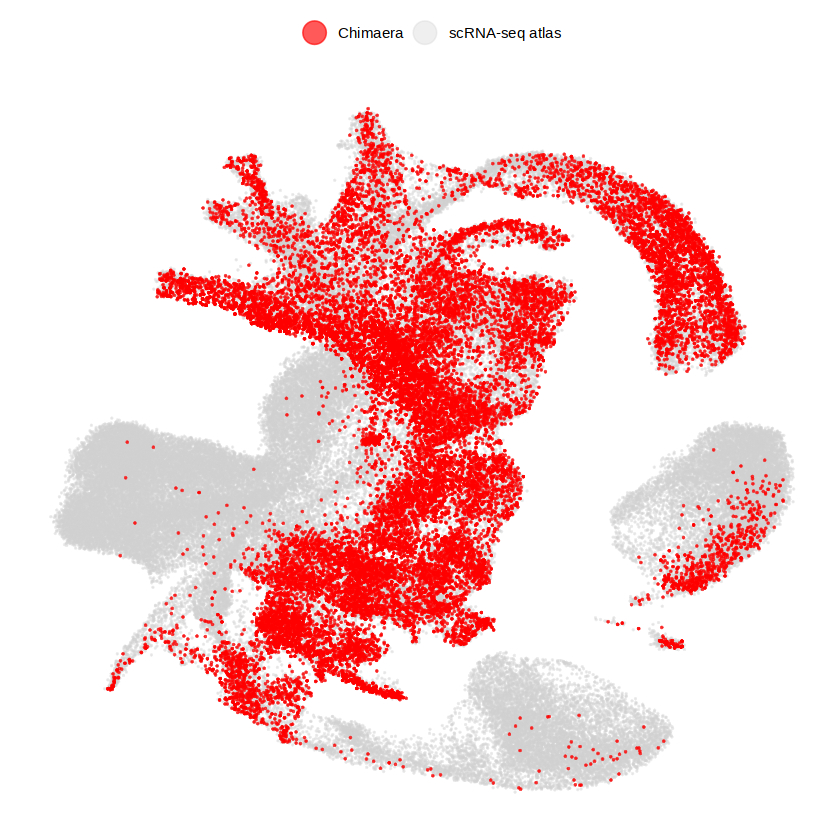

In [7]:
####################
## Plot all cells ##
####################

p <- plot.dimred(to.plot, query.label = "Chimaera", atlas.label = "scRNA-seq atlas")
p

In [8]:

# Dot size
opts$size.mapped <- 0.18
opts$size.nomapped <- 0.1

# Transparency
opts$alpha.mapped <- 0.65
opts$alpha.nomapped <- 0.35

In [9]:
to.plot = rbind(copy(umap.dt)[,tdTom:=TRUE], copy(umap.dt)[,tdTom:=FALSE], sample_metadata) %>% # umap.dt[,tdTom:=TRUE],
    .[,tdTom:=ifelse(tdTom==TRUE, 'KO', 'WT')]

In [10]:
  # Plot
p =  ggplot(to.plot[mapped=='Chimaera'], aes(x=V1, y=V2)) +
    ggrastr::geom_point_rast(data = to.plot[mapped=='scRNA-seq atlas'], 
                             colour='lightgrey', size=opts$size.nomapped , alpha=opts$alpha.nomapped) +
    ggrastr::geom_point_rast(aes(colour=celltype), size=opts$size.mapped , alpha=opts$alpha.mapped) +
    scale_colour_manual(values = opts$celltype.colors) +
    facet_wrap(~tdTom) +
    # labs(x="UMAP Dimension 1", y="UMAP Dimension 2") +
    theme_classic() +
    theme(
      legend.position = "none", 
      text = element_text(size=15), 
      legend.title = element_blank(),
      axis.line = element_blank(),
      axis.text = element_blank(),
      axis.title = element_blank(),
      axis.ticks = element_blank()
    )

p =  ggplot(to.plot[mapped=='Chimaera'], aes(x=V1, y=V2)) +
    ggrastr::geom_point_rast(data = to.plot[mapped=='scRNA-seq atlas'], 
                             colour='lightgrey', size=opts$size.nomapped , alpha=opts$alpha.nomapped) +
    ggrastr::geom_point_rast(aes(colour=celltype_extended), size=opts$size.mapped , alpha=opts$alpha.mapped) +
    scale_colour_manual(values = opts$celltype_extended.colors) +
    facet_wrap(~tdTom) +
    # labs(x="UMAP Dimension 1", y="UMAP Dimension 2") +
    theme_classic() +
    theme(
      legend.position = "none", 
      text = element_text(size=15), 
      legend.title = element_blank(),
      axis.line = element_blank(),
      axis.text = element_blank(),
      axis.title = element_blank(),
      axis.ticks = element_blank()
    )


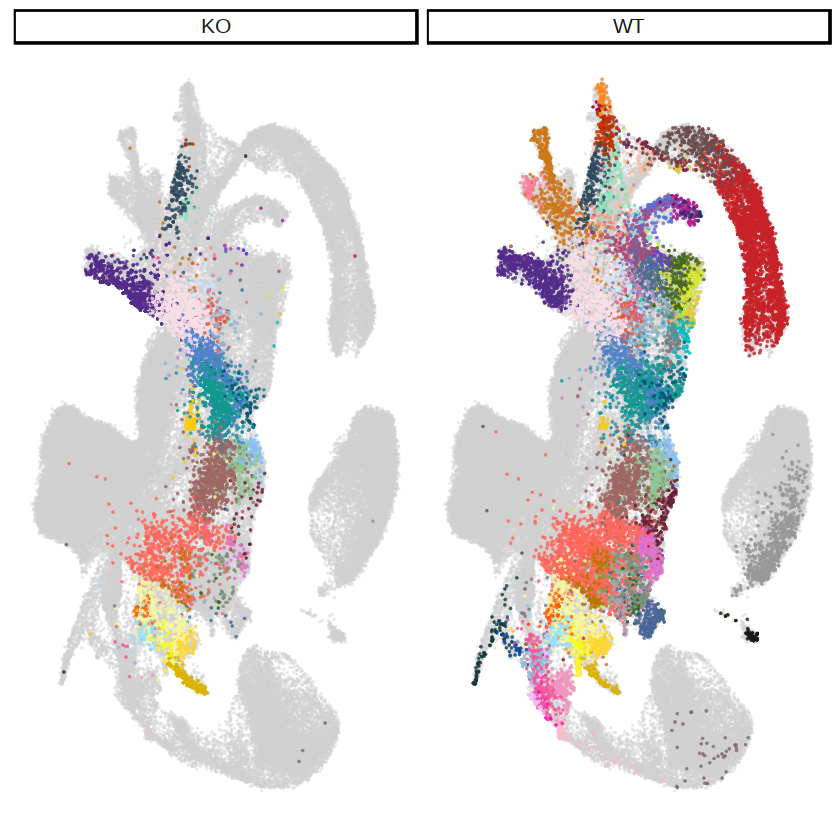

In [11]:
p

In [21]:
head(umap.dt)

cell,V1,V2,celltype,celltype_extended,mapped
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
cell_1,-10.227546,-2.8816875,Epiblast,Epiblast,scRNA-seq atlas
cell_2,-6.625458,0.1089605,Primitive_Streak,Primitive_Streak,scRNA-seq atlas
cell_5,10.061009,-0.0293132,ExE_ectoderm,ExE_ectoderm,scRNA-seq atlas
cell_6,-10.454418,-0.2694517,Epiblast,Epiblast,scRNA-seq atlas
cell_8,-11.047206,-2.2052687,Epiblast,Epiblast,scRNA-seq atlas
cell_9,-11.111009,-2.7534415,Epiblast,Epiblast,scRNA-seq atlas


In [22]:
sample_metadata <- fread(args$query_metadata) %>%
    .[pass_rnaQC==TRUE & sample%in%args$samples & !is.na(closest.cell_mnn)] %>%
    .[, c("closest.cell_mnn","sample", 'celltype.mapped_mnn')] %>%
    setnames('celltype.mapped_mnn', 'celltype') %>% 
    merge(., umap.dt[,c("cell", "V1","V2")], by.x='closest.cell_mnn', by.y='cell') %>%
    setnames(c("closest.cell_mnn"),c("cell")) %>%
    .[, mapped:="Chimaera"] %>%
    .[, c('cell', 'V1', 'V2', 'mapped', 'sample', 'celltype')]

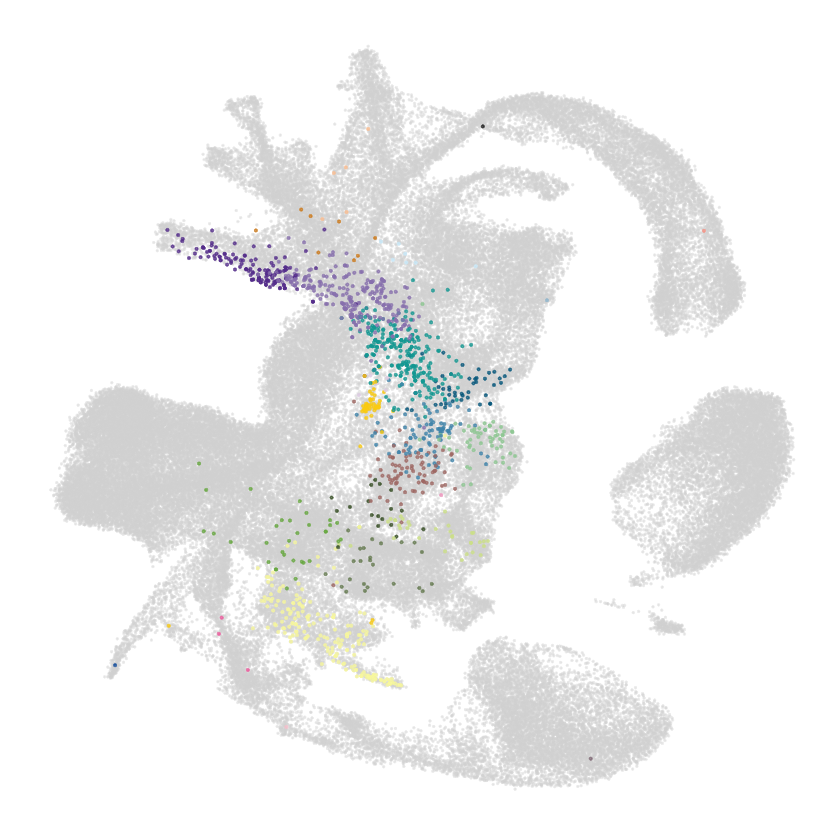

In [25]:

#for (i in 1) {  
    i = args$samples[1]
    to.plot = rbind(umap.dt[,c('cell', 'V1', 'V2', 'mapped')][,`:=`(sample='atlas', celltype=NA)], 
        copy(sample_metadata)[sample==i][,mapped:=sample])
    opts$size.mapped = 0.3

    p =  ggplot(to.plot[mapped==i], aes(x=V1, y=V2)) +
        ggrastr::geom_point_rast(data = to.plot[mapped=='scRNA-seq atlas'], 
                                 colour='lightgrey', size=opts$size.nomapped , alpha=opts$alpha.nomapped) +
        ggrastr::geom_point_rast(aes(colour=celltype), size=opts$size.mapped , alpha=opts$alpha.mapped) +
        scale_colour_manual(values = opts$celltype.colors) +
        theme_classic() +
        theme(
          legend.position = "none", 
          text = element_text(size=15), 
          legend.title = element_blank(),
          axis.line = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          axis.ticks = element_blank()
        )
    
 print(p)
#}
